In [1]:
import numpy as np
import matplotlib.pyplot as plt
import base64
import cv2
from glob import glob
import requests
import json

def decode_base64_and_plot(encoded_string):
    image_bytes = base64.b64decode(encoded_string)
    image_np_array = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np_array, cv2.IMREAD_COLOR)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


url = "http://fishapp.qzenselabs.com/auth/login/"

data = {
    "email": "test@qzense.com",
    "password": "test"
}

headers = {
    "Content-Type": "application/json"
}

response = requests.post(url, data=json.dumps(data), headers=headers)
string_response = response.content.decode()
decoded_data = json.loads(string_response)
access_token = decoded_data['token']['access']

def call_prediction_api(image, species,access_token=access_token):

  url = "http://fishapp.qzenselabs.com/post/"

  headers = {
      "Authorization": "Bearer " + access_token
  }

  data = {
      "hour": 0,
      "flash": "OFF",
      "deviceModel": "a",
      "brand": "b",
      "test": "false",
      "mlModel": "FISH",
      "part": "body",
      "FishName": species
  }

  files = {
      "capture": ("image.jpeg", image),
  }

  response = requests.post(url, data=data, files=files, headers=headers)
  string_response = response.content.decode()
  decoded_data = json.loads(string_response)
  return decode_base64_and_plot(decoded_data['Image'])

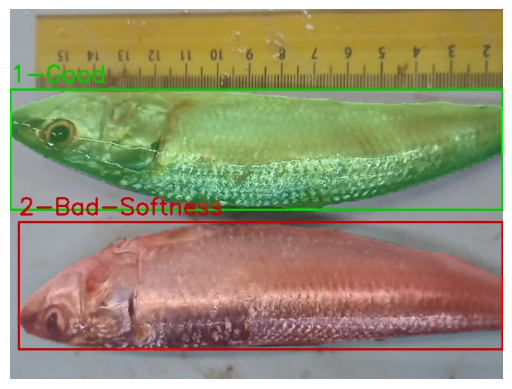

In [4]:
path = r'/content/drive/MyDrive/Sowmya /input/2025-01-21/sardine/Good/2025-01-21_10_18_01_(18776)_sardine_input.jpeg'
with open(path, "rb") as image_file:
    image_data = image_file.read()
call_prediction_api(image_data,'sardine')